In [1]:
# importing libraries
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

In [3]:
def fun(x):
    return 3*x**2 - 4*x + 5

In [4]:
fun(3.2)

22.920000000000005

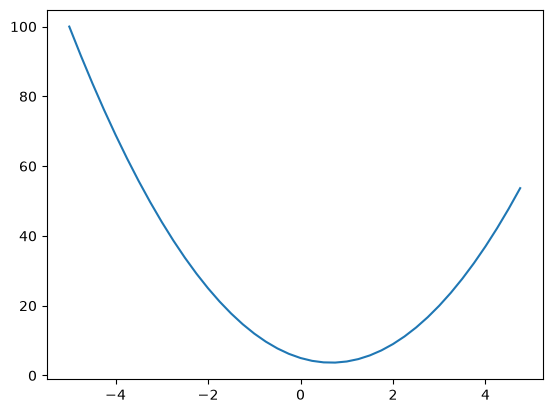

In [5]:
xs = np.arange(-5,5,0.25)
ys = fun(xs)
plt.plot(xs,ys)

In [6]:
h = 0.001
x = 3.0
(fun(x+h)-fun(x))/h

14.00300000000243

## Automatic Differentiation Engine

In [107]:
class Value:
    def __init__(self,data,_children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.prev = set(_children)
        self._backward = lambda : None
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})" 
    def __rmul__(self,other):
        return self * other
    def __radd__(self, other):
        return self + other
    def __sub__(self, other):
        return self + (-other)
    def __neg__(self):
        return self*-1
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other),'+')
        def _backward():
            other.grad += 1.0 * out.grad
            self.grad += 1.0 * out.grad 
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            other.grad += self.data * out.grad
            self.grad += other.data * out.grad 
        out._backward = _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only support int/float pow for now"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                 build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [8]:
a = Value(2.0, label='a')
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b 
e.label = 'e'
d=e+c
d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
d.prev
d._op

'+'

## Creating visualiser


In [9]:
from graphviz import Digraph

def trace(root):
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def drawdot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid+n._op,uid)
    for n1, n2 in edges: 
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    
    return dot

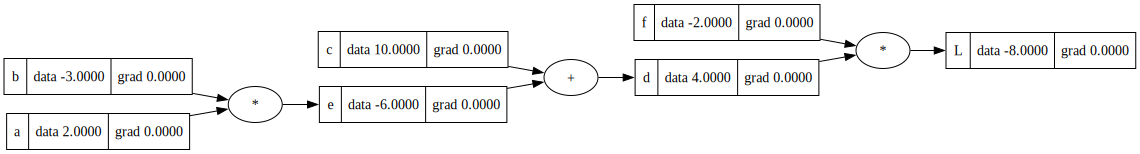

In [10]:
drawdot(L)

In [11]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0

In [12]:
e.grad = -2.0
c.grad = -2.0

In [13]:
a.grad = -3.0 * -2.0
b.grad = 2.0 * -2.0

In [80]:
## Creating small neural network
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n. label = 'n'
# o = n. tanh(); o. label = 'o'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'

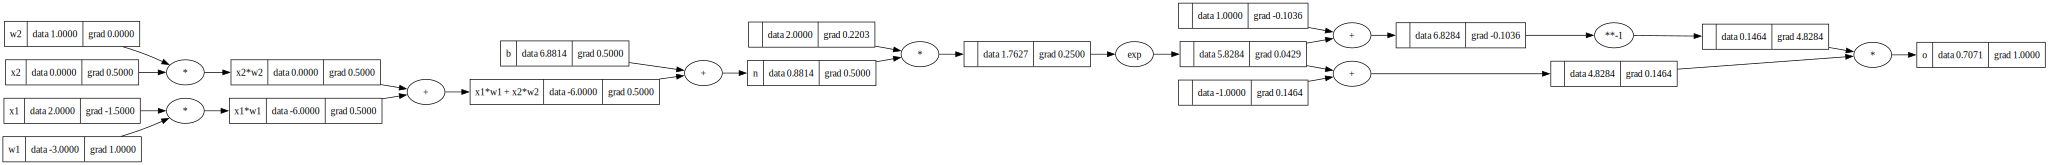

In [84]:
drawdot(o)

In [82]:
o.grad = 1.0

In [83]:
o.backward()

In [46]:
t = Value(2.0)
z = Value(6.0)
t-z

Value(data=-4.0)

In [35]:
t.exp()

Value(data=7.38905609893065)

In [ ]:
n._backward()

In [ ]:
x1w1x2w2._backward()

In [ ]:
x1w1._backward()
x2w2._backward()

In [ ]:
o.grad = 1.0

In [ ]:
n.grad = 1-o.data**2

In [ ]:
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [ ]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [85]:
import torch

In [89]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n= x1*w1 + x2*w2 + b

o = torch.tanh(n)
print(o.data.item())
o.backward()

print(' -- ')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
 -- 
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Building neural network

In [141]:

import random

class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)),self.b)
        out = act.tanh()
        return out
    def paramters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def paramters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.paramters()
            params.extend(ps)
        return params
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self. layers:
            x = layer(x)
        return x
    def paramters(self):
        params = []
        for layer in self.layers:
            ps = layer.paramters()
            params.extend(ps)
        return params


In [168]:
x = [2.0,3.0,-1.0]
# value = Neuron(2)
# value = Layer(2,3)
value = MLP(3,[4,4,1])
value(x)
value.paramters()

[Value(data=0.31132153971377563),
 Value(data=-0.39993102310779505),
 Value(data=0.3125454871766502),
 Value(data=0.12545001317569482),
 Value(data=-0.6688001648352715),
 Value(data=0.3696005970190017),
 Value(data=0.18293900663974094),
 Value(data=0.6292521080664961),
 Value(data=0.2199531314320704),
 Value(data=-0.7217586783256402),
 Value(data=0.9350200432010958),
 Value(data=-0.5789986341315967),
 Value(data=-0.46695674704381385),
 Value(data=-0.34115161316063025),
 Value(data=-0.3377000395840646),
 Value(data=0.4475660373787749),
 Value(data=0.0988183741845432),
 Value(data=-0.7476978218312635),
 Value(data=-0.6402034254124938),
 Value(data=-0.14645226398482647),
 Value(data=-0.23089738257440895),
 Value(data=0.2590785453703559),
 Value(data=0.263720246103021),
 Value(data=-0.382661513672105),
 Value(data=-0.5371450932253969),
 Value(data=-0.36096809143690667),
 Value(data=0.7678702103694843),
 Value(data=0.5798416120682963),
 Value(data=-0.44798636952187887),
 Value(data=0.674836

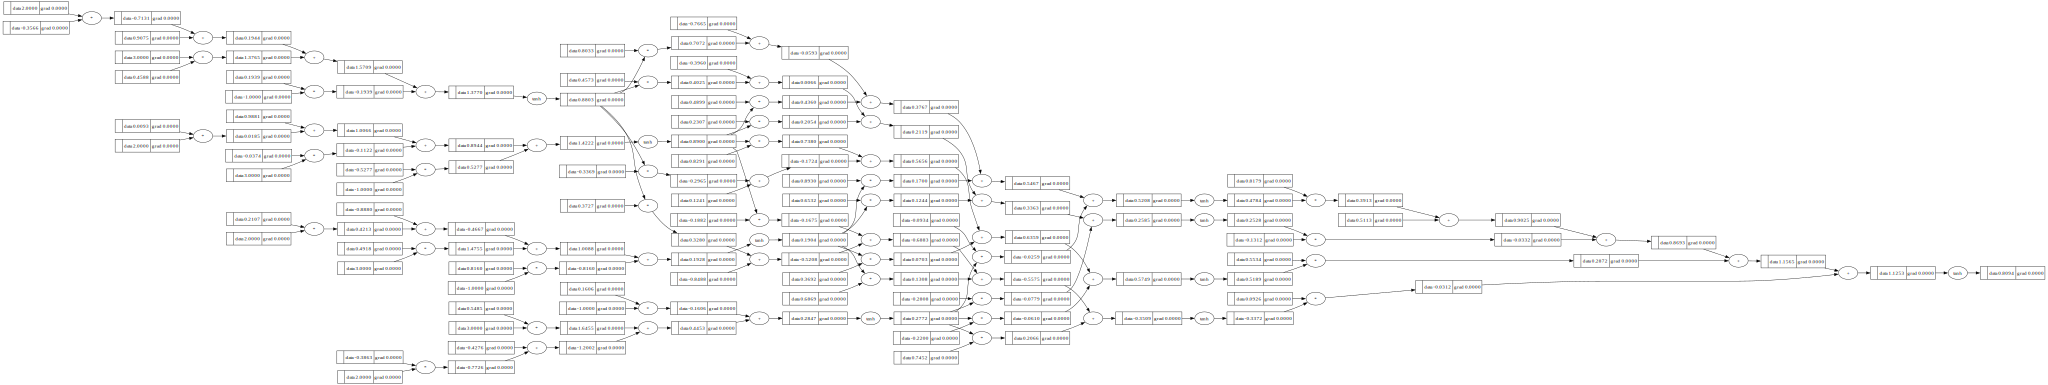

In [132]:
drawdot(value(x))

In [169]:
xs = [[2.0,3.0,-1.0],[3.0,-1.0,0.5],[0.5,1.0,1.0],[1.0,1.0,-1.0]]
ys = [1.0,-1.0,-1.0,1.0]
ypred = [value(s) for s in xs]
ypred

[Value(data=0.6291719857257678),
 Value(data=-0.41278980246398056),
 Value(data=-0.28501511459000495),
 Value(data=-0.5622437995107485)]

In [153]:
## loss calculation
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred)) 
loss

Value(data=2.987386631202879)

In [159]:

loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred)) 
loss

Value(data=7.9835139218324525)

In [160]:
loss.backward()

In [161]:
value.layers[0].neurons[0].w[0].grad

0.6397226599215818

In [162]:
value.layers[0].neurons[0].w[0].data

0.016171061336035963

In [157]:
for p in value.paramters():
    p.data += 0.01 + p.grad

In [170]:
for k in range(20):
    ## forward pass
    ypred = [value(s) for s in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred)) 
    ## back propagation
    for p in value.paramters():
        p.grad = 0.0
    loss.backward()

    ## update
    for p in value.paramters():
        p.data += -0.05 + p.grad
    
    print(k,loss.data)
    

0 3.4341383077353846
1 15.951099194872638
2 15.971915314823852
3 15.976656964482252
4 15.979534567269155
5 15.983348100600388
6 15.984657774478155
7 15.987204894939929
8 15.987145608946216
9 15.989974606344301
10 15.987799002605357
11 15.992980237573017
12 15.985910617023876
13 15.996359103966627
14 15.989940420705228
15 15.994842228907803
16 15.986895831875586
17 15.99772834880915
18 15.994498125419584
19 15.990011925795828


In [171]:
ypred

[Value(data=-0.9999093331494672),
 Value(data=0.9999836001988756),
 Value(data=0.99772187205286),
 Value(data=-0.9998868732592457)]

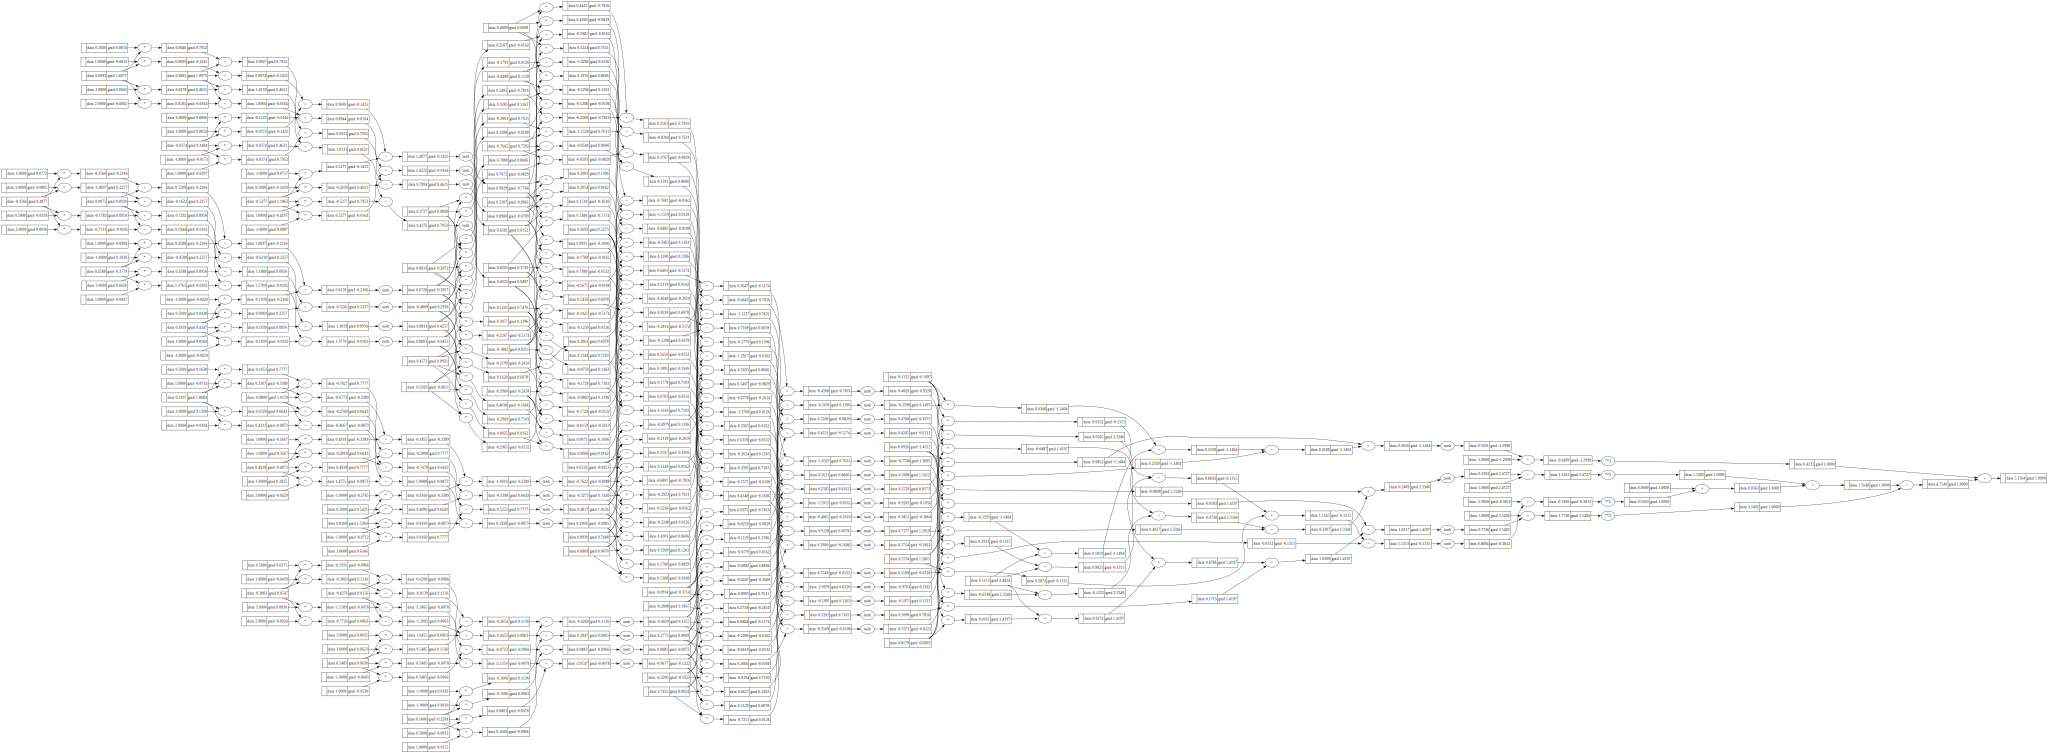

In [140]:
drawdot(loss)